# Required Libraries

The following libraries are necessary for this project:

* `numpy`
* `pandas`
* `matplotlib`
* `sklearn` (scikit-learn)
* `m2cgen`

---

### Installation
To install any of these libraries, use the command:

```bash
!pip install library_name

In [1]:
!pip install m2cgen
# use this in google colab as other library are available by default


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.2/92.2 kB 3.4 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report # Added classification_report
import m2cgen as m2c  # This library converts Python models to C for Arduino/ESP32

In [7]:
# --- 1. LOAD DATASET ---
# Define column names (64 pixels + 1 label)
columns = ['pixel_{}'.format(i) for i in range(64)] + ['label']

# Load your balanced dataset
df = pd.read_csv('thermal_data.csv', header=None, names=columns)

print(f"Loaded {len(df)} samples.")
print(df['label'].value_counts())


# --- 2. PREPARE DATA FOR MODEL ---

# Separate features (X) and text labels (y_labels)
# We keep 'X' original for visualization later
X = df.drop('label', axis=1)
y_labels = df['label']

# Perform Row-wise Normalization (Standardization)
# This forces the model to learn "shape" by removing the background temperature.
# We add 1e-8 to prevent division by zero if an "empty" frame has 0 variation.
print("Normalizing data (row-wise)...")
X_norm = X.apply(lambda row: (row - row.mean()) / (row.std() + 1e-8), axis=1)

# Perform Label Encoding (e.g., 'animal' -> 0, 'empty' -> 1, 'human' -> 2)
# We save the encoder 'le' so we can get the names for the report
le = LabelEncoder()
y = le.fit_transform(y_labels)

print("Data ready for training.\n")


Loaded 51 samples.
label
animal    19
empty     18
human     14
Name: count, dtype: int64
Normalizing data (row-wise)...
Data ready for training.



#Spliting and training and visualizing

Model Accuracy: 90.91%

Classification Report:
              precision    recall  f1-score   support

      animal       1.00      1.00      1.00         4
       empty       0.80      1.00      0.89         4
       human       1.00      0.67      0.80         3

    accuracy                           0.91        11
   macro avg       0.93      0.89      0.90        11
weighted avg       0.93      0.91      0.91        11



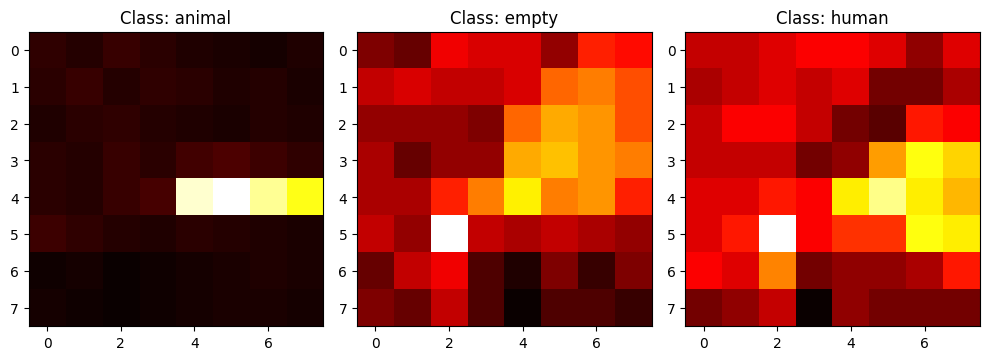

In [8]:
# Split into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X_norm, y, test_size=0.2)

# --- 2. TRAIN THE MODEL ---
# We use a 'linear' kernel because it is FASTEST on ESP32
clf = svm.SVC(kernel='linear')
clf.fit(X_train, y_train)

# --- 3. EVALUATE AND VISUALIZE RESULTS ---
# Verify accuracy
print(f"Model Accuracy: {clf.score(X_test, y_test) * 100:.2f}%")

# Get class names from LabelEncoder for consistent plotting and reporting
target_names = le.classes_
classes_for_plotting = le.classes_

# Display full classification report
print("\nClassification Report:")
print(classification_report(y_test, clf.predict(X_test), target_names=target_names))

# This helps you understand what the SVM is looking at
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for i in range(len(classes_for_plotting)): # Iterate through all unique classes
    # Find the first index for each class in the original dataset
    indices = np.where(y == i)[0]
    if len(indices) > 0:
        idx = indices[0]
        axes[i].imshow(X.iloc[idx].values.reshape(8, 8), cmap='hot', interpolation='nearest') # Use .iloc and .values
        axes[i].set_title(f"Class: {classes_for_plotting[i]}")
    else:
        axes[i].set_title(f"Class: {classes_for_plotting[i]} (No sample)") # Handle cases where a class might not be present
plt.tight_layout()
plt.show()
#this is perfectly generated data so accuracy is 100 if accuracy is low for real data use rbf
# clf = svm.SVC(kernel='rbf', C=1.0, gamma='scale') in place of clf =
# svm.SVC(kernel='linear')

#Creating pipe line for  C ++

In [9]:
# Convert to C code
print("Converting SVM to C...")
code = m2c.export_to_c(clf)

# Save file
with open("perimeter_model.h", "w") as f:
    f.write(code)

print("SUCCESS! SVM model saved.")

Converting SVM to C...
SUCCESS! SVM model saved.
